#### **Análisis y Procesamiento de Señales**
# **Trabajo Práctico Nº4: "Primeras nociones de estimación espectral"**
#### Federico Dunel
## **Introducción**

En el siguiente trabajo se realizó una matriz de 1000x200 cuyas columnas estan conformadas por funciones senoidales. El argumento de cada una se realizó agregandole un valor aleatorio con distribución uniforme entre -2 y 2 alrededor de un valor de frecuencia igual a la mitad de Nyquist. A esta matriz se le agregó otro valor aleatorio simulando el ruido de una señal con una distribución normal con una varianza que depende del valor de SNR buscado. Luego se calcularon las PSD de todas las señales aplicando distintas ventanas con el fin de comparar el sesgo y la varianza de los resultados de cada una. 



## **Analisis de datos**

1) Generacion de las variables y funciones utilizadas.

In [1]:
from numpy.fft import fft
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as win

N = 1000
fs = N
df = fs/N
R = 200 #cantidad señales de muestra

SNR = 3

amp = 2
Px = (amp**2)/2
Pn = Px/(10**(SNR/10))


#ruidos
n = np.random.normal(0,Pn,N)
Fr = np.random.uniform(-2,2,R)

# ejes para hacer matrices para llenar de senoidales

tt = np.arange(N) * 1/fs
tt = tt.reshape(-1,1)

F1 = N/4 + Fr
ff1 = F1.reshape(1,-1)


matriz_ruido = np.tile(n.reshape(-1,1), (1,R))

matriz_argumento = 2*np.pi*(fs/N)*ff1*tt

#matriz de senoidales completa
xx = amp * np.sin(matriz_argumento) + matriz_ruido


2) Luego se calcularon las PSD multiplicando la matriz por distintas ventanas, se limitó el eje x en las PSD ventaneadas para apreciar mejor los maximos de la funcion

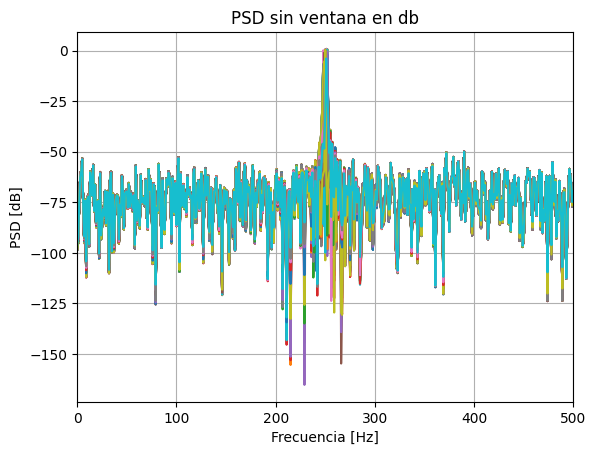

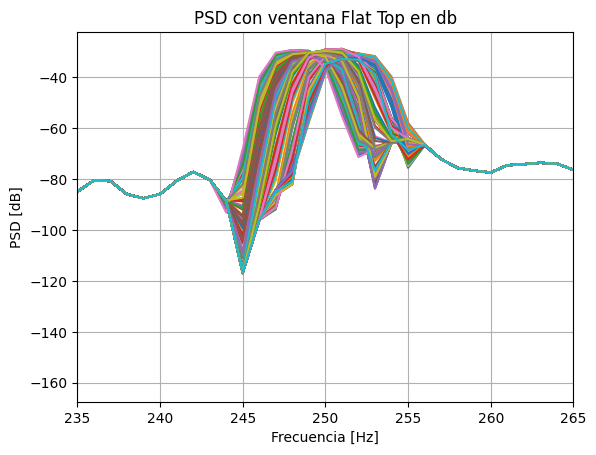

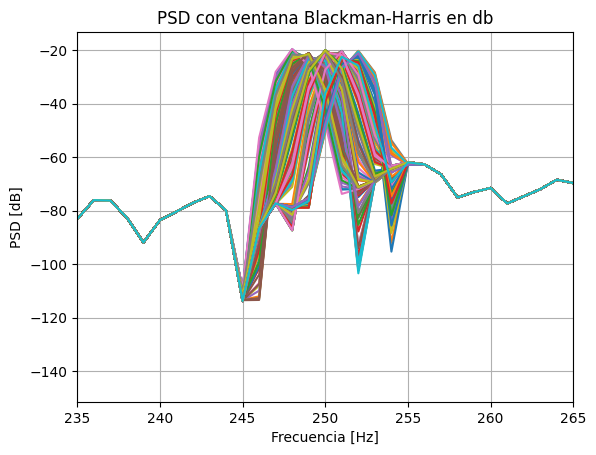

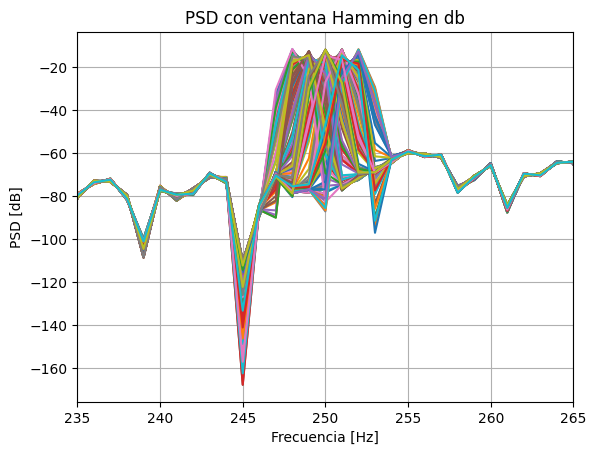

In [12]:
X= (1/N)*fft(xx, axis = 0)
Xabs = np.abs(X)
PSDdb = 10*np.log(Xabs**2 + 1e-15)

# armo ventanas

flattop = win.flattop(N).reshape(-1,1)
blackmanh = win.blackmanharris(N).reshape(-1,1)
hamming = win.hamming(N).reshape(-1,1)

#PSD ventaneada sin padding

XXflattop = fft(xx*flattop, axis=0, n=N)/N
XXblackmanh = fft(xx*blackmanh, axis=0, n=N)/N
XXhamming = fft(xx*hamming, axis=0, n=N)/N

PSDflattop = np.abs(XXflattop)**2
PSDblackmanh = np.abs(XXblackmanh)**2
PSDhamming = np.abs(XXhamming)**2

PSDdbflattop = 10*np.log(PSDflattop)
PSDdbblackmanh = 10*np.log(PSDblackmanh)
PSDdbhamming = 10*np.log(PSDhamming)


plt.figure(1)
plt.plot(PSDdb)
plt.xlim(0, N/2)
plt.title('PSD sin ventana en db')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()
plt.show()


# PSD ventaneada sin padding

frec = np.arange(0, N)

plt.figure(2)
plt.plot(frec, PSDdbflattop)
plt.xlim([(N/4)-15, (N/4)+15])
plt.title('PSD con ventana Flat Top en db')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()
plt.show()

plt.figure(3)
plt.plot(frec, PSDdbblackmanh)
plt.xlim([(N/4)-15, (N/4)+15])
plt.title('PSD con ventana Blackman-Harris en db')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()
plt.show()

plt.figure(4)
plt.plot(frec, PSDdbhamming)
plt.xlim([(N/4)-15, (N/4)+15])
plt.title('PSD con ventana Hamming en db')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()
plt.show()


3) Tabla de sesgo y varianza en base a estimadores de amplitud y frecuencia

Tabla de amplitud:

In [16]:

#Estimadores de amplitud
amplitud_rectangular = Xabs[N//4,:]**2
amplitud_flattop = PSDflattop[(N//4),:]
amplitud_blackmanh = PSDblackmanh[(N//4),:]
amplitud_hamming = PSDhamming[(N//4),:]

# Estimadores de frecuencia
frec_rect = np.argmax(Xabs[:N//2,:]**2, axis=0)*df
frec_flattop = np.argmax(PSDflattop[:N//2,:], axis=0)*df
frec_blackmanh = np.argmax(PSDblackmanh[:N//2,:], axis=0)*df
frec_hamming = np.argmax(PSDhamming[:N//2,:], axis=0)*df

# Sesgo y varianza de amplitud
amp_teorica = 1
frec_teorica = 250

sesgo_amp_rect = np.mean(amplitud_rectangular) - amp_teorica
var_amp_rect = np.var(amplitud_rectangular)

sesgo_amp_flattop = np.mean(amplitud_flattop) - amp_teorica
var_amp_flattop = np.var(amplitud_flattop)

sesgo_amp_blackmanh = np.mean(amplitud_blackmanh) - amp_teorica
var_amp_blackmanh = np.var(amplitud_blackmanh)

sesgo_amp_hamming = np.mean(amplitud_hamming) - amp_teorica
var_amp_hamming = np.var(amplitud_hamming)

# Sesgo y varianza de frecuencia

sesgo_frec_rect = np.mean(frec_rect) - frec_teorica
var_frec_rect = np.var(frec_rect)

sesgo_frec_flattop = np.mean(frec_flattop) - frec_teorica
var_frec_flattop = np.var(frec_flattop)

sesgo_frec_blackmanh = np.mean(frec_blackmanh) - frec_teorica
var_frec_blackmanh = np.var(frec_blackmanh)

sesgo_frec_hamming = np.mean(frec_hamming) - frec_teorica
var_frec_hamming = np.var(frec_hamming)


# ===== Tabla =====

print('\n{:^20} {:^15} {:^15}'.format('Ventana', 'Sesgo', 'Varianza'))
print('-'*50)

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Rectangular',
    sesgo_amp_rect,
    var_amp_rect))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Flat Top',
    sesgo_amp_flattop,
    var_amp_flattop))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Blackman-Harris',
    sesgo_amp_blackmanh,
    var_amp_blackmanh))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Hamming',
    sesgo_amp_hamming,
    var_amp_hamming))


      Ventana             Sesgo         Varianza    
--------------------------------------------------
    Rectangular       -7.439355e-01   1.224996e-01  
      Flat Top        -9.606072e-01   8.432449e-05  
  Blackman-Harris     -9.353520e-01   1.945486e-03  
      Hamming         -8.978544e-01   1.160700e-02  


Se puede apreciar como en la ventana Flat top el sesgo es significativamente menor que al resto sin embargo cuenta con el mayor sesgo  

Tabla de frecuencia:

In [17]:

print('\n{:^20} {:^15} {:^15}'.format('Ventana', 'Sesgo', 'Varianza'))
print('-'*50)

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Rectangular',
    sesgo_frec_rect,
    var_frec_rect))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Flat Top',
    sesgo_frec_flattop,
    var_amp_flattop))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Blackman-Harris',
    sesgo_frec_blackmanh,
    var_frec_blackmanh))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Hamming',
    sesgo_frec_hamming,
    var_frec_hamming))


      Ventana             Sesgo         Varianza    
--------------------------------------------------
    Rectangular       1.250000e-01    1.469375e+00  
      Flat Top        -3.000000e-02   8.432449e-05  
  Blackman-Harris     1.100000e-01    1.457900e+00  
      Hamming         1.200000e-01    1.455600e+00  


En este caso la ventana Flat Top cuenta con un sesgo significativamente menor, al igual que la varianza. 
Luego se realizaron histogramas con los valores de los estimadores para poder ver graficamente los resultados de las tablas

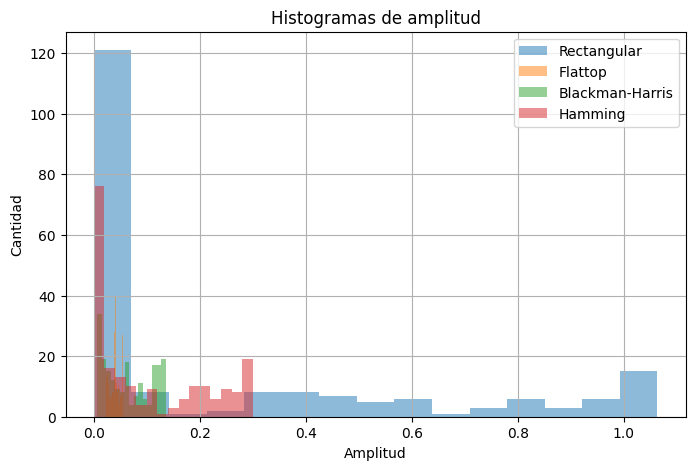

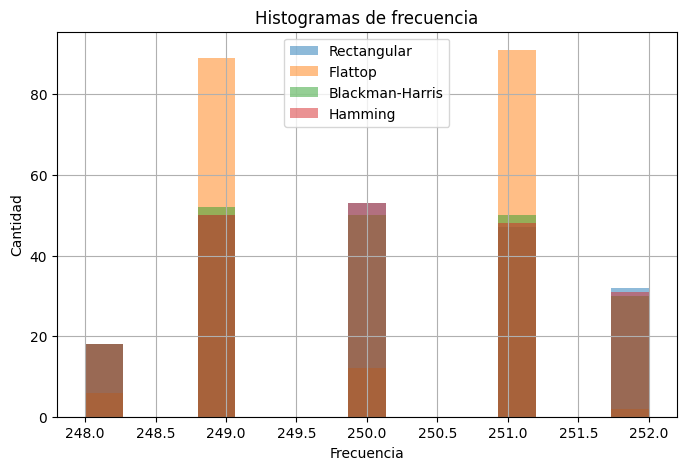

In [19]:

plt.figure(figsize=(8,5))

plt.hist(amplitud_rectangular, bins=15, alpha=0.5, label='Rectangular')

plt.hist(amplitud_flattop, bins=15, alpha=0.5, label='Flattop')

plt.hist(amplitud_blackmanh, bins=15, alpha=0.5, label='Blackman-Harris')

plt.hist(amplitud_hamming, bins=15, alpha=0.5, label='Hamming')

plt.title('Histogramas de amplitud')
plt.xlabel('Amplitud')
plt.ylabel('Cantidad')
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.hist(frec_rect, bins=15, alpha=0.5, label='Rectangular')

plt.hist(frec_flattop, bins=15, alpha=0.5, label='Flattop')

plt.hist(frec_blackmanh, bins=15, alpha=0.5, label='Blackman-Harris')

plt.hist(frec_hamming, bins=15, alpha=0.5, label='Hamming')

plt.title('Histogramas de frecuencia')
plt.xlabel('Frecuencia')
plt.ylabel('Cantidad')
plt.legend()
plt.grid(True)

plt.show()


4) Mismo Analísis con SNR 10db

In [24]:
N = 1000
fs = N
df = fs/N
R = 200 #cantidad señales de muestra

SNR = 10

amp = 2
Px = (amp**2)/2
Pn = Px/(10**(SNR/10))


#ruidos
n = np.random.normal(0,Pn,N)
Fr = np.random.uniform(-2,2,R)

# ejes para hacer matrices para llenar de senoidales

tt = np.arange(N) * 1/fs
tt = tt.reshape(-1,1)

F1 = N/4 + Fr
ff1 = F1.reshape(1,-1)


matriz_ruido = np.tile(n.reshape(-1,1), (1,R))

matriz_argumento = 2*np.pi*(fs/N)*ff1*tt

#matriz de senoidales completa
xx = amp * np.sin(matriz_argumento) + matriz_ruido

#PSD
X= (1/N)*fft(xx, axis = 0)
Xabs = np.abs(X)
PSDdb = 10*np.log(Xabs**2 + 1e-15)

XXflattop = fft(xx*flattop, axis=0, n=N)/N
XXblackmanh = fft(xx*blackmanh, axis=0, n=N)/N
XXhamming = fft(xx*hamming, axis=0, n=N)/N

PSDflattop = np.abs(XXflattop)**2
PSDblackmanh = np.abs(XXblackmanh)**2
PSDhamming = np.abs(XXhamming)**2

#Estimadores de amplitud
amplitud_rectangular = Xabs[N//4,:]**2
amplitud_flattop = PSDflattop[(N//4),:]
amplitud_blackmanh = PSDblackmanh[(N//4),:]
amplitud_hamming = PSDhamming[(N//4),:]

# Estimadores de frecuencia
frec_rect = np.argmax(Xabs[:N//2,:]**2, axis=0)*df
frec_flattop = np.argmax(PSDflattop[:N//2,:], axis=0)*df
frec_blackmanh = np.argmax(PSDblackmanh[:N//2,:], axis=0)*df
frec_hamming = np.argmax(PSDhamming[:N//2,:], axis=0)*df

# Sesgo y varianza de amplitud
amp_teorica = 1
frec_teorica = 250

sesgo_amp_rect = np.mean(amplitud_rectangular) - amp_teorica
var_amp_rect = np.var(amplitud_rectangular)

sesgo_amp_flattop = np.mean(amplitud_flattop) - amp_teorica
var_amp_flattop = np.var(amplitud_flattop)

sesgo_amp_blackmanh = np.mean(amplitud_blackmanh) - amp_teorica
var_amp_blackmanh = np.var(amplitud_blackmanh)

sesgo_amp_hamming = np.mean(amplitud_hamming) - amp_teorica
var_amp_hamming = np.var(amplitud_hamming)

# Sesgo y varianza de frecuencia

sesgo_frec_rect = np.mean(frec_rect) - frec_teorica
var_frec_rect = np.var(frec_rect)

sesgo_frec_flattop = np.mean(frec_flattop) - frec_teorica
var_frec_flattop = np.var(frec_flattop)

sesgo_frec_blackmanh = np.mean(frec_blackmanh) - frec_teorica
var_frec_blackmanh = np.var(frec_blackmanh)

sesgo_frec_hamming = np.mean(frec_hamming) - frec_teorica
var_frec_hamming = np.var(frec_hamming)

print("Tabla de sesgo y varianza de amplitud")

print('\n{:^20} {:^15} {:^15}'.format('Ventana', 'Sesgo', 'Varianza'))
print('-'*50)

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Rectangular',
    sesgo_amp_rect,
    var_amp_rect))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Flat Top',
    sesgo_amp_flattop,
    var_amp_flattop))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Blackman-Harris',
    sesgo_amp_blackmanh,
    var_amp_blackmanh))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Hamming',
    sesgo_amp_hamming,
    var_amp_hamming))

print("Tabla de sesgo y varianza de frecuencia")

print('\n{:^20} {:^15} {:^15}'.format('Ventana', 'Sesgo', 'Varianza'))
print('-'*50)

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Rectangular',
    sesgo_frec_rect,
    var_frec_rect))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Flat Top',
    sesgo_frec_flattop,
    var_amp_flattop))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Blackman-Harris',
    sesgo_frec_blackmanh,
    var_frec_blackmanh))

print('{:^20} {:^15.6e} {:^15.6e}'.format(
    'Hamming',
    sesgo_frec_hamming,
    var_frec_hamming))



Tabla de sesgo y varianza de amplitud

      Ventana             Sesgo         Varianza    
--------------------------------------------------
    Rectangular       -7.667209e-01   1.071867e-01  
      Flat Top        -9.611652e-01   7.666421e-05  
  Blackman-Harris     -9.374132e-01   1.873188e-03  
      Hamming         -9.025021e-01   1.093963e-02  
Tabla de sesgo y varianza de frecuencia

      Ventana             Sesgo         Varianza    
--------------------------------------------------
    Rectangular       1.100000e-01    1.537900e+00  
      Flat Top        8.000000e-02    7.666421e-05  
  Blackman-Harris     1.150000e-01    1.531775e+00  
      Hamming         1.150000e-01    1.531775e+00  


5) Analisis del estimador de frecuencia con SNR de 3db y aplicando zero padding

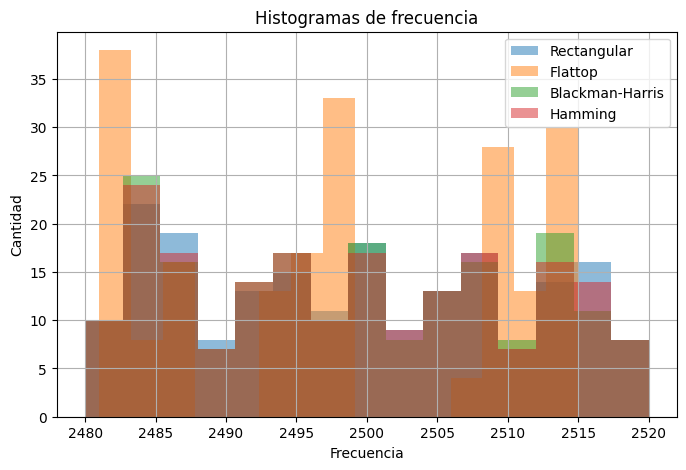

In [25]:
N = 1000
fs = N
df = fs/N
R = 200 #cantidad señales de muestra

SNR = 3

amp = 2
Px = (amp**2)/2
Pn = Px/(10**(SNR/10))


#ruidos
n = np.random.normal(0,Pn,N)
Fr = np.random.uniform(-2,2,R)

# ejes para hacer matrices para llenar de senoidales

tt = np.arange(N) * 1/fs
tt = tt.reshape(-1,1)

F1 = N/4 + Fr
ff1 = F1.reshape(1,-1)


matriz_ruido = np.tile(n.reshape(-1,1), (1,R))

matriz_argumento = 2*np.pi*(fs/N)*ff1*tt

#matriz de senoidales completa
xx = amp * np.sin(matriz_argumento) + matriz_ruido


#PSD ventaneada con padding

factor_escala = 10

X= (1/N)*fft(xx, axis = 0, n=10*N)
Xabs = np.abs(X)
PSD = Xabs**2
PSDdb = 10*np.log(PSD + 1e-15)



XXflattop = fft(xx*flattop, axis=0, n=10*N)/N
XXblackmanh = fft(xx*blackmanh, axis=0, n=10*N)/N
XXhamming = fft(xx*hamming, axis=0, n=10*N)/N

PSDflattop = np.abs(XXflattop)**2
PSDblackmanh = np.abs(XXblackmanh)**2
PSDhamming = np.abs(XXhamming)**2

frec_padding = np.arange(0, factor_escala*N)/factor_escala

#Estimadores de amplitud
amplitud_rectangular = Xabs[N*factor_escala//4,:]**2
amplitud_flattop = PSDflattop[(N*factor_escala//4),:]
amplitud_blackmanh = PSDblackmanh[(N*factor_escala//4),:]
amplitud_hamming = PSDhamming[(N*factor_escala//4),:]

# Estimadores de frecuencia
frec_rect = np.argmax(Xabs[:N*factor_escala//2,:]**2, axis=0)*df
frec_flattop = np.argmax(PSDflattop[:N*factor_escala//2,:], axis=0)*df
frec_blackmanh = np.argmax(PSDblackmanh[:N*factor_escala//2,:], axis=0)*df
frec_hamming = np.argmax(PSDhamming[:N*factor_escala//2,:], axis=0)*df

plt.figure(figsize=(8,5))

plt.hist(frec_rect, bins=15, alpha=0.5, label='Rectangular')

plt.hist(frec_flattop, bins=15, alpha=0.5, label='Flattop')

plt.hist(frec_blackmanh, bins=15, alpha=0.5, label='Blackman-Harris')

plt.hist(frec_hamming, bins=15, alpha=0.5, label='Hamming')

plt.title('Histogramas de frecuencia')
plt.xlabel('Frecuencia')
plt.ylabel('Cantidad')
plt.legend()
plt.grid(True)

plt.show()




Al realizar zero padding puede apreciarse mejor la distribucion uniforme de la frecuencia entre 248 y 250, todo multiplicado por el factor de escala del padding que es igual a 10